# GFS forecasts, just using a convenient scratch pad here 

In [27]:
gfs = xr.open_dataset('https://tds.gdex.ucar.edu/thredds/dodsC/aggregations/g/d083003/1/d083003-2015')
gfs

<xarray.Dataset> Size: 4TB
Dimensions:                                                                     (
                                                                                 lat: 721,
                                                                                 lon: 1440,
                                                                                 reftime: 708,
                                                                                 timeOffset: 3,
                                                                                 validtime1Offset: 3,
                                                                                 ...
                                                                                 height_above_ground_layer_bounds_1: 2,
                                                                                 height_above_ground_layer1_bounds_1: 2,
                                                                                 pressure_difference_layer1_bounds_1: 2,
                                                                                 sigma_layer_bounds_1: 2,
                                                                                 depth_below_surface_layer_bounds_1: 2,
                                                                                 pressure_difference_layer2_bounds_1: 2)
Coordinates: (12/28)
  * lat                                                                         (lat) float32 3kB ...
  * lon                                                                         (lon) float32 6kB ...
  * reftime                                                                     (reftime) datetime64[ns] 6kB ...
  * timeOffset                                                                  (timeOffset) float64 24B ...
    time                                                                        (reftime, timeOffset) datetime64[ns] 17kB ...
  * validtime1Offset                                                            (validtime1Offset) float64 24B ...
    ...                                                                          ...
  * height_above_ground2                                                        (height_above_ground2) float32 4B ...
  * height_above_ground3                                                        (height_above_ground3) float32 8B ...
  * potential_vorticity_surface                                                 (potential_vorticity_surface) float32 8B ...
  * pressure_difference_layer2                                                  (pressure_difference_layer2) float32 8B ...
  * sigma                                                                       (sigma) float32 4B ...
  * height_above_ground4                                                        (height_above_ground4) float32 12B ...
Dimensions without coordinates: timeOffset_bounds_1, time_bounds_2,
                                pressure_difference_layer_bounds_1,
                                height_above_ground_layer_bounds_1,
                                height_above_ground_layer1_bounds_1,
                                pressure_difference_layer1_bounds_1,
                                sigma_layer_bounds_1,
                                depth_below_surface_layer_bounds_1,
                                pressure_difference_layer2_bounds_1
Data variables: (12/145)
    LatLon_Projection                                                           int32 4B ...
    timeOffset_bounds                                                           (timeOffset, timeOffset_bounds_1) float64 48B ...
    time_bounds                                                                 (reftime, timeOffset, time_bounds_2) datetime64[ns] 34kB ...
    pressure_difference_layer_bounds                                            (pressure_difference_layer, pressure_difference_layer_bounds_1) float32 8B ...
    height_above_ground_layer_bounds                         

In [28]:
gfs.Geopotential_height_isobaric

<xarray.DataArray 'Geopotential_height_isobaric' (reftime: 708,
                                                  validtime2Offset: 4,
                                                  isobaric2: 26, lat: 721,
                                                  lon: 1440)> Size: 306GB
[76447687680 values with dtype=float32]
Coordinates:
  * lat               (lat) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * lon               (lon) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * reftime           (reftime) datetime64[ns] 6kB 2015-07-08 ... 2015-12-31T...
  * validtime2Offset  (validtime2Offset) float64 32B 0.0 3.0 6.0 9.0
    validtime2        (reftime, validtime2Offset) datetime64[ns] 23kB ...
  * isobaric2         (isobaric2) float32 104B 1e+03 2e+03 ... 9.75e+04 1e+05
Attributes: (12/13)
    long_name:                       Geopotential height @ Isobaric surface
    units:                           gpm
    abbreviation:                    HGT
    grid_mapping:                    LatLon_Projection
    Grib_Variable_Id:                VAR_0-3-5_L100
    Grib2_Parameter:                 [0 3 5]
    ...                              ...
    Grib2_Parameter_Category:        Mass
    Grib2_Parameter_Name:            Geopotential height
    Grib2_Level_Type:                100
    Grib2_Level_Desc:                Isobaric surface
    Grib2_Generating_Process_Type:   Forecast
    Grib2_Statistical_Process_Type:  UnknownStatType--1

In [31]:
gfs.Geopotential_height_isobaric.sel(reftime='2015-02-02', isobaric2=50000, method = 'nearest')

<xarray.DataArray 'Geopotential_height_isobaric' (validtime2Offset: 4,
                                                  lat: 721, lon: 1440)> Size: 17MB
[4152960 values with dtype=float32]
Coordinates:
  * lat               (lat) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * lon               (lon) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    reftime           datetime64[ns] 8B 2015-07-08
  * validtime2Offset  (validtime2Offset) float64 32B 0.0 3.0 6.0 9.0
    validtime2        (validtime2Offset) datetime64[ns] 32B ...
    isobaric2         float32 4B 5e+04
Attributes: (12/13)
    long_name:                       Geopotential height @ Isobaric surface
    units:                           gpm
    abbreviation:                    HGT
    grid_mapping:                    LatLon_Projection
    Grib_Variable_Id:                VAR_0-3-5_L100
    Grib2_Parameter:                 [0 3 5]
    ...                              ...
    Grib2_Parameter_Category:        Mass
    Grib2_Parameter_Name:            Geopotential height
    Grib2_Level_Type:                100
    Grib2_Level_Desc:                Isobaric surface
    Grib2_Generating_Process_Type:   Forecast
    Grib2_Statistical_Process_Type:  UnknownStatType--1

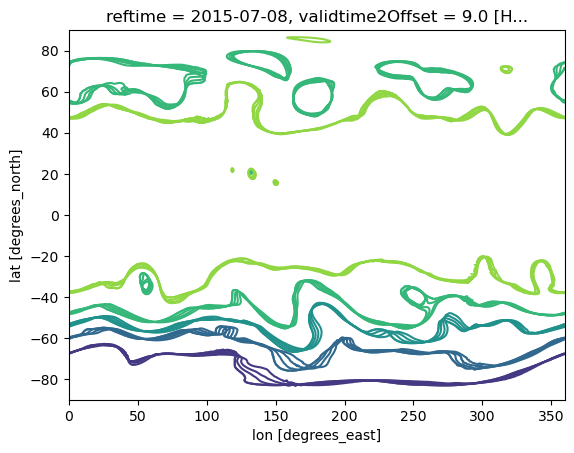

In [38]:
gfs.Geopotential_height_isobaric. \
    sel(reftime='2015-02-02', isobaric2=50000, method = 'nearest'). \
    isel(validtime2Offset=0).plot.contour()

for ilead in range(4): 
    gfs.Geopotential_height_isobaric. \
        sel(reftime='2015-02-02', isobaric2=50000, method = 'nearest'). \
        isel(validtime2Offset=ilead).plot.contour()

In [12]:
#ds = xr.open_dataset('/Users/bmapes/Box/Jazz-Brian-Africa-organization_of_convection/Amazon_JF2025/AllHourly.nc')
#Tb = ds.Tb.interpolate_na(dim="lon", method="linear", max_gap=2)
#b[:,::2,::2].astype('float32')

<xarray.DataArray 'Tb' (time: 1416, lat: 275, lon: 275)> Size: 428MB
array([[[281.     , 285.     , 291.     , ..., 262.     , 260.     ,
         264.     ],
        [283.     , 288.     , 293.     , ..., 261.     , 259.     ,
               nan],
        [280.     , 286.     , 292.     , ..., 260.     , 259.     ,
         258.     ],
        ...,
        [206.     , 205.     , 203.     , ..., 290.     , 289.     ,
         273.     ],
        [205.     , 204.     , 203.     , ..., 283.     , 284.     ,
         284.     ],
        [206.     , 206.     , 205.     , ..., 289.     , 284.     ,
         283.     ]],

       [[282.     , 284.     , 283.     , ..., 273.     , 262.     ,
         254.     ],
        [277.     , 282.     , 287.     , ..., 274.     , 274.     ,
         272.     ],
        [282.     , 286.     , 288.     , ..., 269.     , 265.66666,
         263.     ],
...
        [295.     , 295.     , 295.     , ..., 263.     , 252.     ,
         246.     ],
        [295.     , 295.     , 295.     , ..., 277.     , 255.     ,
         249.     ],
        [295.     , 295.     , 295.     , ..., 267.     , 256.     ,
         248.     ]],

       [[283.     , 264.     , 235.     , ..., 286.     , 275.     ,
         257.     ],
        [282.     , 280.     , 263.     , ..., 283.     , 254.     ,
         250.     ],
        [278.     , 285.     , 278.     , ..., 281.     , 262.     ,
         258.     ],
        ...,
        [294.     , 294.     , 294.     , ..., 276.     , 270.     ,
         255.     ],
        [294.     , 294.     , 294.     , ..., 266.     , 269.     ,
         255.     ],
        [294.     , 294.     , 294.     , ..., 263.     , 275.     ,
         259.     ]]], shape=(1416, 275, 275), dtype=float32)
Coordinates:
  * lon      (lon) float32 1kB -59.97 -59.9 -59.82 ... -40.18 -40.11 -40.03
  * lat      (lat) float32 1kB -19.99 -19.92 -19.85 ... -0.2001 -0.1273 -0.05458
  * time     (time) datetime64[ns] 11kB 2025-01-01 ... 2025-02-28T23:00:00.00...
Attributes:
    units:          K
    standard_name:  brightness_temperature